# Lab 2 - Part I: Biến đổi điểm ảnh (Point Operations)

In [3]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image = cv2.imread('../data/input/anh.jpg')
image = image[:, :, ::-1]  # BGR -> RGB
print(f'Image loaded: {image.shape}, dtype={image.dtype}')

Image loaded: (914, 735, 3), dtype=uint8


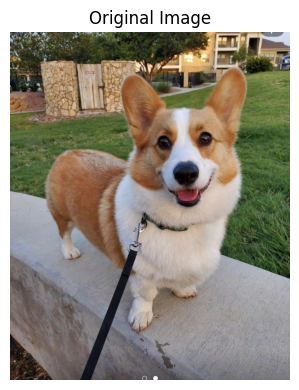

In [2]:
plt.figure(figsize=(5, 4))
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 1. Thay đổi độ sáng (Brightness Adjustment)
- Công thức: `new_pixel = old_pixel + factor`
- `factor > 0`: ảnh sáng hơn; `factor < 0`: ảnh tối hơn
- Dùng `np.float32` trung gian để tránh tràn số, `np.clip(..., 0, 255)` giữ giá trị trong [0,255]

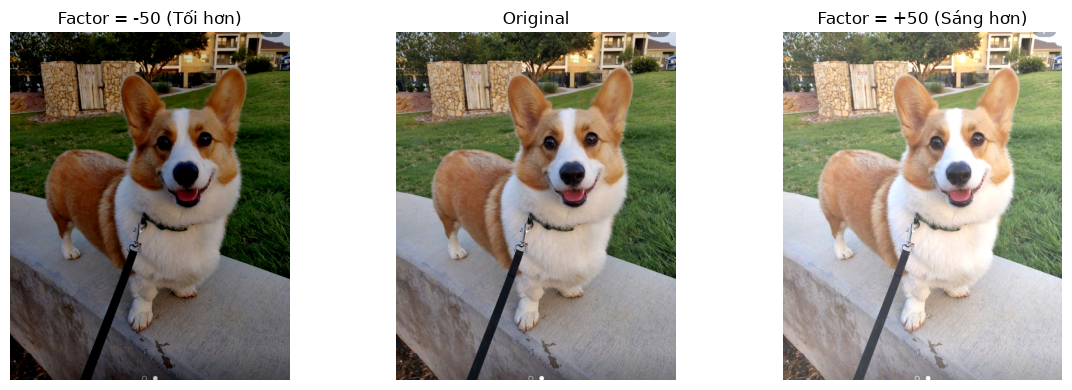

[OK] Saved: output/part1_point_ops/brightness_dark.jpg
[OK] Saved: output/part1_point_ops/brightness_bright.jpg


In [4]:
# factor = -50 (tối) và factor = +50 (sáng)
bright = np.clip(image.astype(np.float32) + 50, 0, 255).astype(np.uint8)
dark = np.clip(image.astype(np.float32) - 50, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(dark)
axes[0].set_title('Factor = -50 (Tối hơn)')
axes[0].axis('off')
axes[1].imshow(image)
axes[1].set_title('Original')
axes[1].axis('off')
axes[2].imshow(bright)
axes[2].set_title('Factor = +50 (Sáng hơn)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

os.makedirs('output/part1_point_ops', exist_ok=True)
cv2.imwrite('output/part1_point_ops/brightness_dark.jpg', cv2.cvtColor(dark, cv2.COLOR_RGB2BGR))
cv2.imwrite('output/part1_point_ops/brightness_bright.jpg', cv2.cvtColor(bright, cv2.COLOR_RGB2BGR))
print('[OK] Saved: output/part1_point_ops/brightness_dark.jpg')
print('[OK] Saved: output/part1_point_ops/brightness_bright.jpg')

---
## 2. Thay đổi độ tương phản (Contrast Adjustment)
- Công thức: `new_pixel = old_pixel * factor`
- `factor > 1`: tăng tương phản; `0 < factor < 1`: giảm tương phản
- Dùng `np.float32` trung gian, `np.clip(..., 0, 255)`

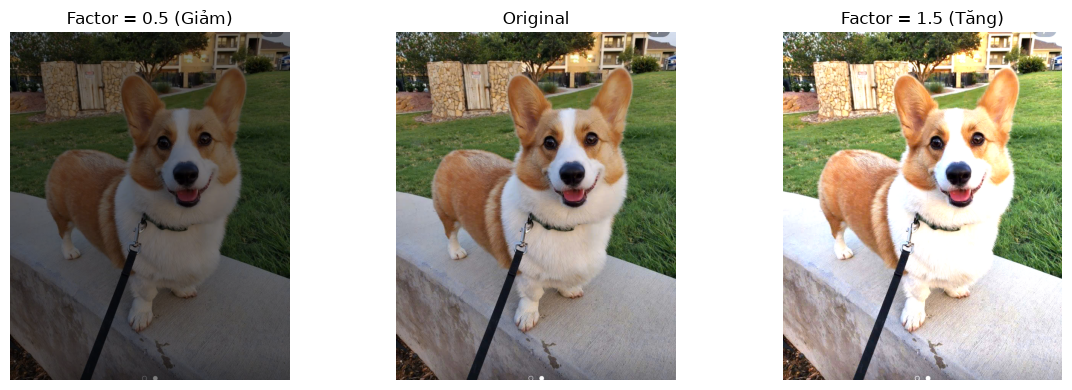

[OK] Saved: output/part1_point_ops/contrast_reduced.jpg
[OK] Saved: output/part1_point_ops/contrast_increased.jpg


In [5]:
# factor = 0.5 (giảm) và factor = 1.5 (tăng)
low_contrast = np.clip(image.astype(np.float32) * 0.5, 0, 255).astype(np.uint8)
high_contrast = np.clip(image.astype(np.float32) * 1.5, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(low_contrast)
axes[0].set_title('Factor = 0.5 (Giảm)')
axes[0].axis('off')
axes[1].imshow(image)
axes[1].set_title('Original')
axes[1].axis('off')
axes[2].imshow(high_contrast)
axes[2].set_title('Factor = 1.5 (Tăng)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('output/part1_point_ops/contrast_reduced.jpg', cv2.cvtColor(low_contrast, cv2.COLOR_RGB2BGR))
cv2.imwrite('output/part1_point_ops/contrast_increased.jpg', cv2.cvtColor(high_contrast, cv2.COLOR_RGB2BGR))
print('[OK] Saved: output/part1_point_ops/contrast_reduced.jpg')
print('[OK] Saved: output/part1_point_ops/contrast_increased.jpg')

---
## 3. Biến đổi âm bản (Negative Transform)
- Công thức: `new_pixel = 255 - old_pixel`
- Đảo ngược toàn bộ giá trị màu, tạo hiệu ứng phim âm bản
- Áp dụng đồng thời trên cả 3 kênh R, G, B

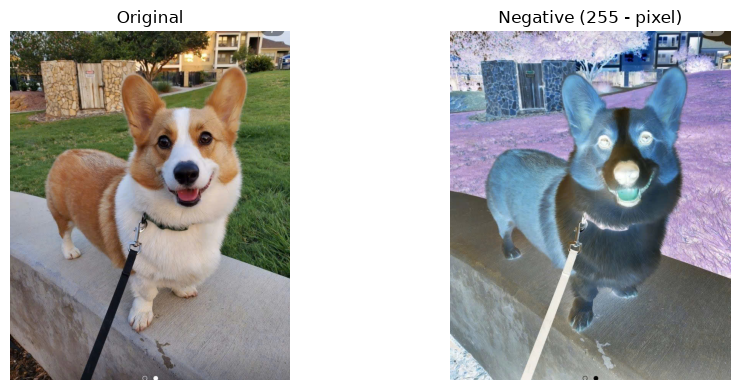

[OK] Saved: output/part1_point_ops/negative.jpg


In [6]:
negative = 255 - image

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(negative)
axes[1].set_title('Negative (255 - pixel)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('output/part1_point_ops/negative.jpg', cv2.cvtColor(negative, cv2.COLOR_RGB2BGR))
print('[OK] Saved: output/part1_point_ops/negative.jpg')

---
## 4. Cắt ngưỡng nhị phân (Binary Thresholding)
- Chuyển ảnh sang grayscale trước
- Công thức: `pixel = 255 nếu pixel > threshold, ngược lại = 0`
- `threshold = 128` cho kết quả phân tách rõ ràng giữa vùng sáng và vùng tối

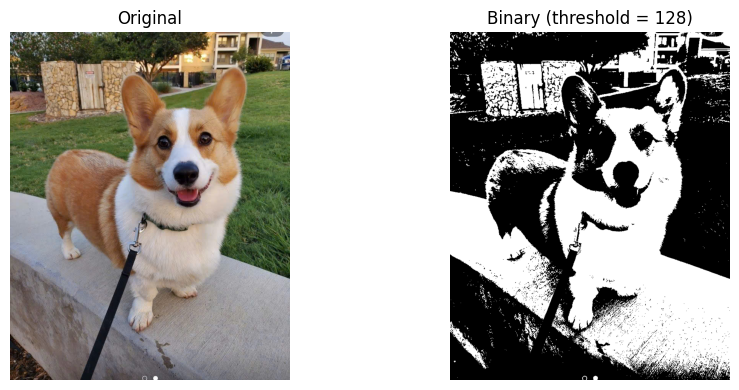

[OK] Saved: output/part1_point_ops/binary_threshold.jpg


In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
_, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary (threshold = 128)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('output/part1_point_ops/binary_threshold.jpg', binary)
print('[OK] Saved: output/part1_point_ops/binary_threshold.jpg')

---
## Tổng kết Part I

| STT | Tác vụ | Công thức | Output file |
|-----|--------|-----------|-------------|
| 1 | Độ sáng (tối) | `pixel - 50` | `brightness_dark.jpg` |
| 2 | Độ sáng (sáng) | `pixel + 50` | `brightness_bright.jpg` |
| 3 | Tương phản (giảm) | `pixel * 0.5` | `contrast_reduced.jpg` |
| 4 | Tương phản (tăng) | `pixel * 1.5` | `contrast_increased.jpg` |
| 5 | Âm bản | `255 - pixel` | `negative.jpg` |
| 6 | Cắt ngưỡng | `if pixel > 128 → 255` | `binary_threshold.jpg` |

**Kết luận:** Các phép biến đổi điểm ảnh đơn giản, nhanh, trực tiếp trên từng pixel. Phù hợp cho điều chỉnh tổng thể ảnh.